# LeetCode #485: Max Consecutive Ones

https://leetcode.com/problems/max-consecutive-ones/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | O(n²) | O(1) |
| **Single Pass** | O(n) | O(1) |

---

## Understanding the Methods

### Brute Force
For each index, scan forward while values are 1 and track the run length. Each element starts its own scan — O(n) per start × n starts = O(n²) worst case on all-ones input.

### Optimal: Single Pass ★
Maintain one rolling counter `cur` that increments on 1 and resets to 0 on 0. Update `max` each step. One sweep, two integers, no restarts.

**Why this is better than Brute Force:** Single Pass visits every element exactly once. Brute Force re-traverses already-counted runs, wasting O(n) per starting index in the worst case.

**Constraints:**
* 1 ≤ nums.length ≤ 10⁵
* nums[i] is either 0 or 1

## Solutions
### C#

In [ ]:
public class Solution {
    public int FindMaxConsecutiveOnes(int[] nums) {
        int cur = 0, max = 0;
        foreach (int n in nums) {
            // Extend the run on 1; reset to zero on 0
            cur = n == 1 ? cur + 1 : 0;
            if (cur > max) max = cur;
        }
        return max;
    }
}

### Python

In [ ]:
from typing import List

class Solution:
    def findMaxConsecutiveOnes(self, nums: List[int]) -> int:
        cur = max_ones = 0
        for n in nums:
            # Extend the run on 1; reset to zero on 0
            cur = cur + 1 if n == 1 else 0
            if cur > max_ones:
                max_ones = cur
        return max_ones

### Go

In [ ]:
package main

func findMaxConsecutiveOnes(nums []int) int {
	cur, maxOnes := 0, 0
	for _, n := range nums {
		// Extend the run on 1; reset to zero on 0
		if n == 1 {
			cur++
		} else {
			cur = 0
		}
		if cur > maxOnes {
			maxOnes = cur
		}
	}
	return maxOnes
}

### Rust

In [ ]:
impl Solution {
    pub fn find_max_consecutive_ones(nums: Vec<i32>) -> i32 {
        let (mut cur, mut max_ones) = (0i32, 0i32);
        for &n in &nums {
            // Extend the run on 1; reset to zero on 0
            cur = if n == 1 { cur + 1 } else { 0 };
            if cur > max_ones { max_ones = cur; }
        }
        max_ones
    }
}

## Example Scenarios

**1. Common Case — nums = [1, 1, 0, 1, 1, 1]**

**Input:** Two runs: length 2 and length 3.

`cur` trace: 1→2→0→1→2→3. `max` trace: 1→2→2→2→2→3.
The second run beats the first at the final step.

---

**2. Slightly Complex — nums = [1, 0, 1, 1, 0, 1] (multiple runs, tie at the end)**

**Input:** Three runs of lengths 1, 2, 1.

`cur`: 1→0→1→2→0→1. `max` locks in at 2 after the second run and stays — the final singleton can't overtake it. No run ties the max in this example, confirming `max` persists across resets.

---

**3. Edge Case: Time Factor — all ones: nums = [1, 1, 1, …, 1] (n = 10⁵)**

**Input:** One run spanning the entire array.

`cur` counts 1→2→3→…→n without ever resetting. `max` updates every iteration. Brute Force restarts from each index: total work = $1+2+\ldots+n = O(n^2) \approx 5 \times 10^9$ comparisons. Single Pass: exactly n iterations.

---

**4. Edge Case: Space Factor — all zeros: nums = [0, 0, 0, 0]**

**Input:** No run of ones exists.

`cur` stays 0 throughout; `max` never exceeds 0. Only two integer variables allocated — `cur` and `max` — regardless of n. Returns 0 correctly.

---

**5. Almost-Impossible but Plausible — single element**

**Input:** nums = [1] and nums = [0].

For [1]: cur→1, max→1, return 1. For [0]: cur stays 0, max stays 0, return 0.
Both are handled in one iteration with no branching on array length — the loop body covers all cases.

## Infographic

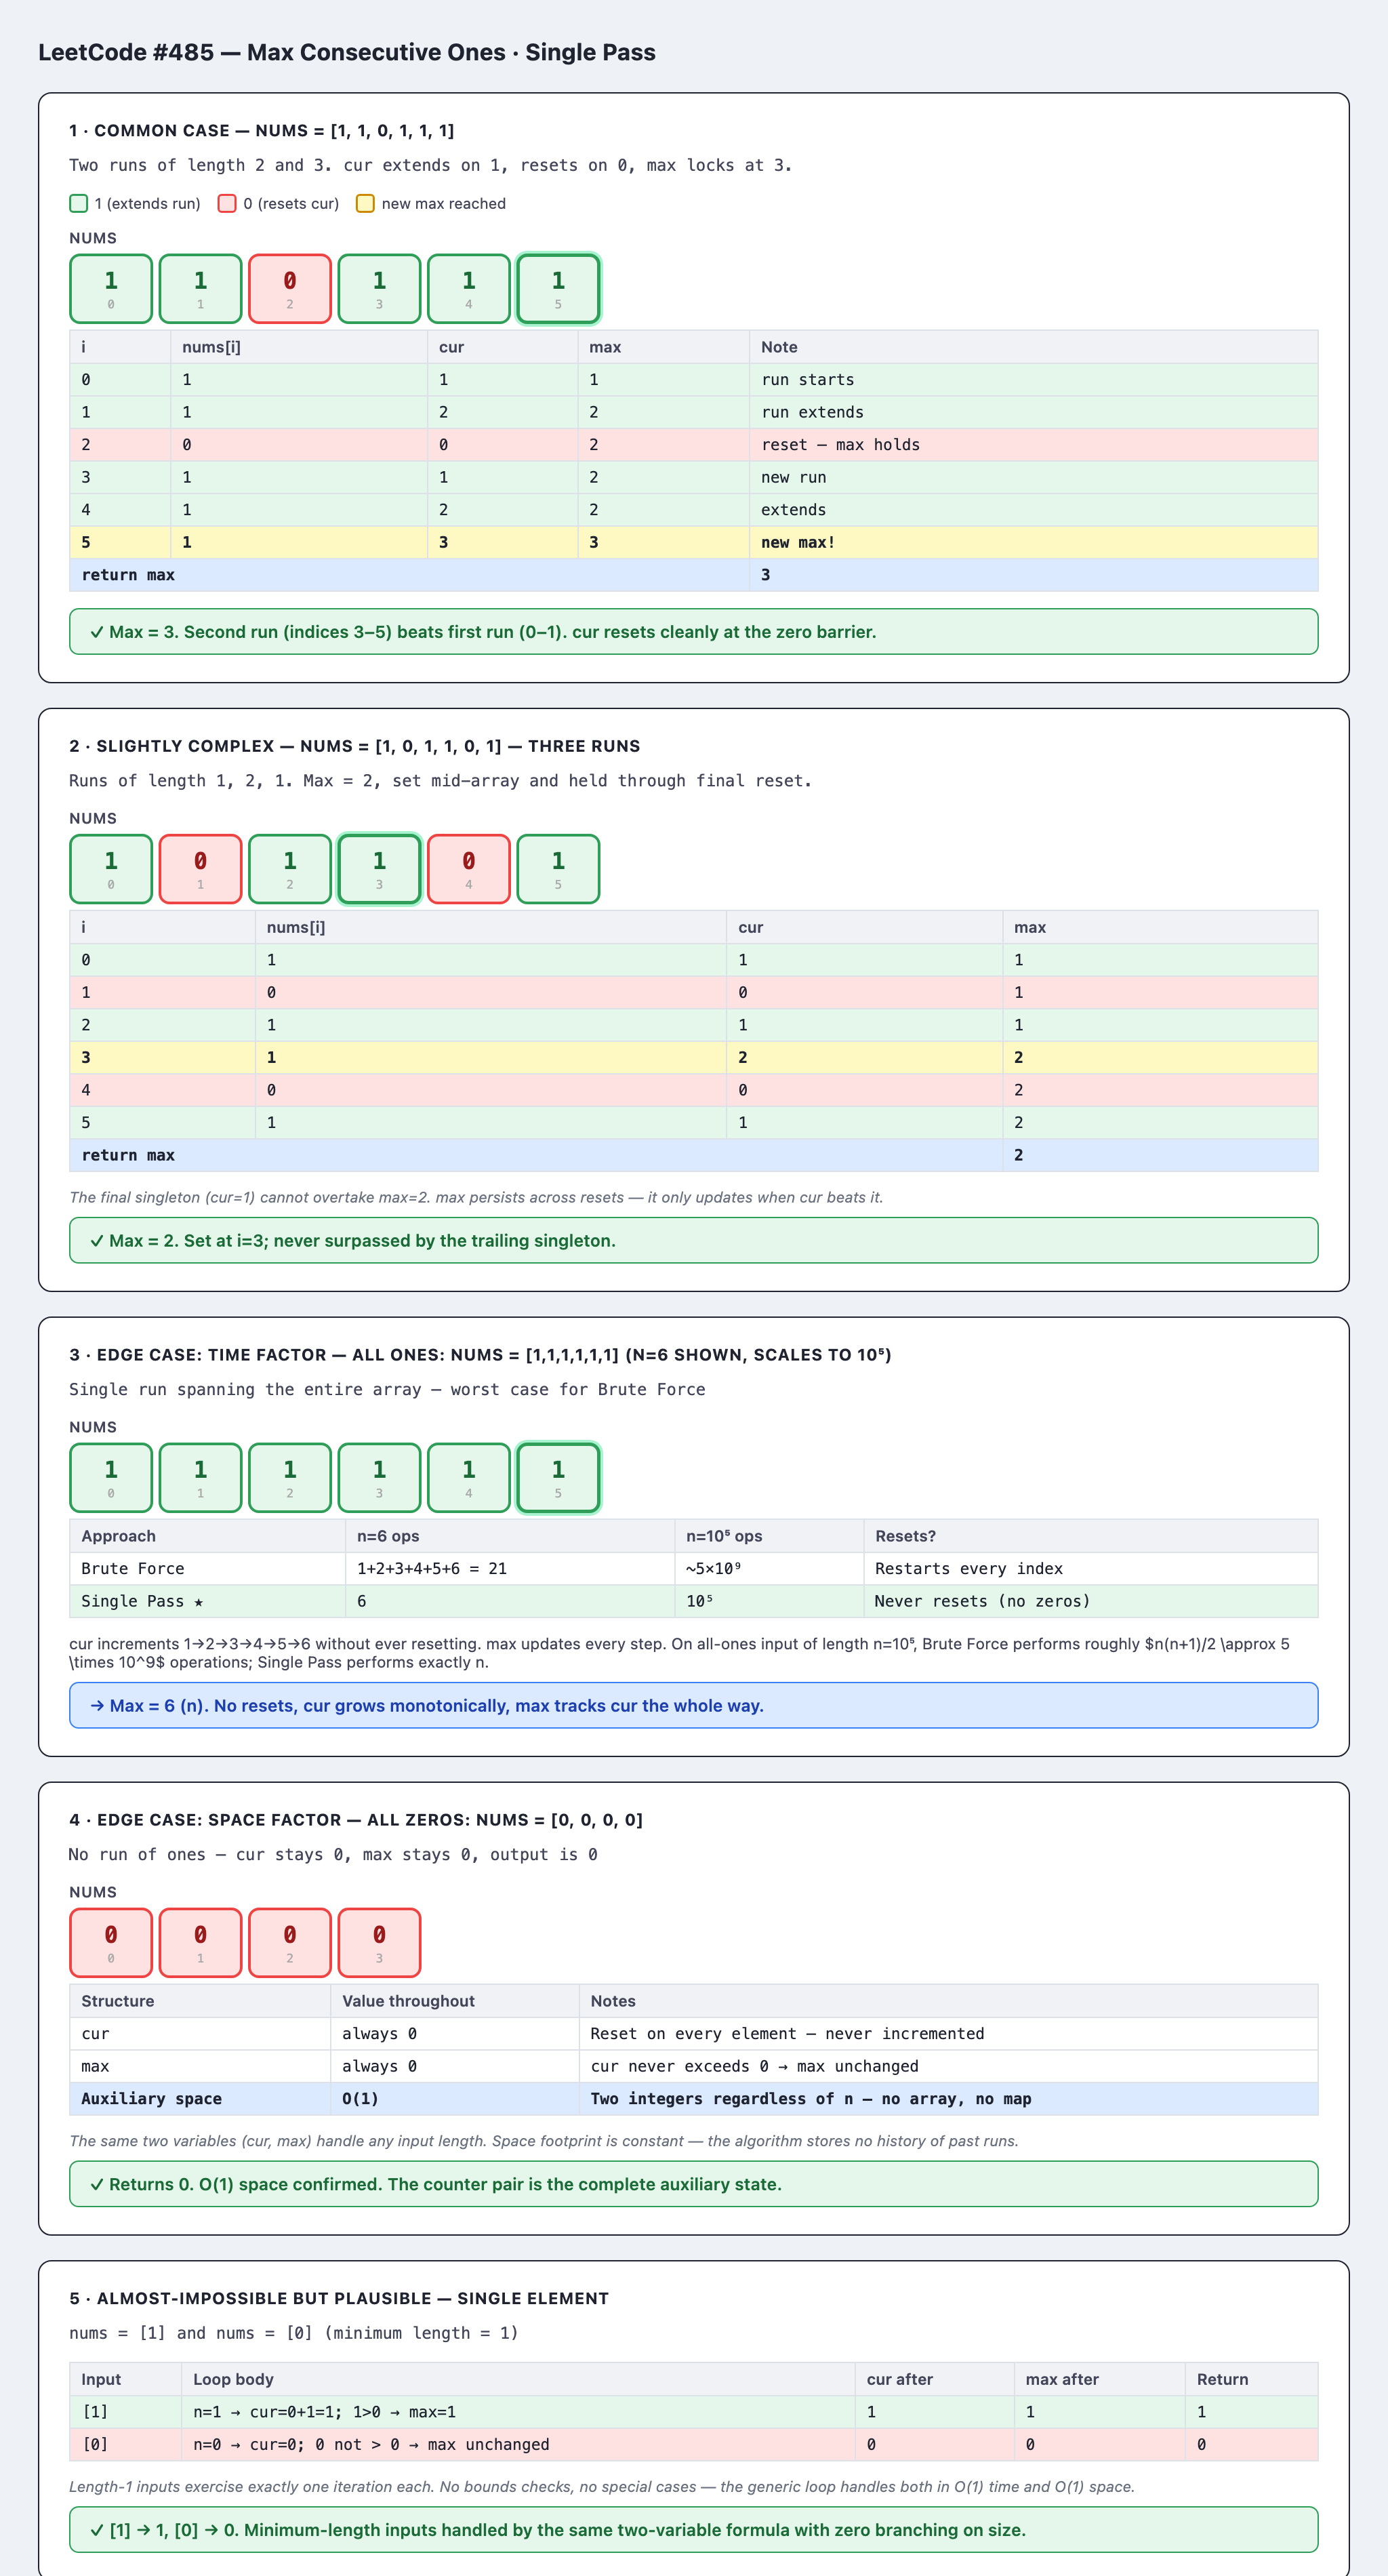